# Singapore HDB Resale Price Prediction

This notebook builds and compares several models to predict **`resale_price`** from the Singapore HDB resale dataset.

Included:
- dataset overview and statistical summary
- feature engineering
- train / validation / test split
- Linear Regression
- Polynomial Regression
- Random Forest
- k-Nearest Neighbors
- Neural Network (MLP)
- optional XGBoost and LightGBM
- model comparison
- SHAP feature importance for the best tree-based model
- PCA, t-SNE, and UMAP visualizations
- Singapore heatmaps and geospatial maps using latitude / longitude

## Notes on speed and compatibility

1. Your local `scikit-learn` version appears to be older, so this notebook avoids `mean_squared_error(..., squared=False)`.
2. **Random Forest** and **MLP** can be slow on this dataset, especially after geocoding adds more columns.
   To make the notebook practical for local use:
   - tuning is done on a **sample** of the training set
   - a **progress bar** is shown with `tqdm`
   - the final fitted model for Random Forest / MLP can also use a **reduced training sample**
   - the parameter grids are intentionally kept small and focused
3. XGBoost / LightGBM / SHAP / UMAP are included as **optional** sections. If the package is not installed locally, the notebook will skip that section gracefully and tell you what to install.
4. Because you already added building geocodes, this version also includes **maps of Singapore** using the latitude / longitude fields.

In [97]:

# Optional installs (uncomment only if needed in your environment)
# %pip install tqdm umap-learn shap xgboost lightgbm


In [98]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import itertools
import math
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LogNorm

from tqdm.auto import tqdm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import contextily as cx
import geopandas as gpd
from shapely.geometry import Point
from matplotlib.colors import Normalize, TwoSlopeNorm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 1. Import data

Import CSV data

In [99]:
# Update this path if your CSV is saved somewhere else.
DATA_PATH = Path("ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(226916, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [100]:
def preprocess_hdb_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["floor_area_sqm"] = pd.to_numeric(df["floor_area_sqm"], errors="coerce")
    df["resale_price"] = pd.to_numeric(df["resale_price"], errors="coerce")

    df["block"] = df["block"].astype(str).str.strip()
    df["street_name"] = df["street_name"].astype(str).str.strip()
    df["address"] = (
        df["block"] + " " + df["street_name"]
    ).str.replace(r"\s+", " ", regex=True).str.strip()

    df = df.dropna(subset=["floor_area_sqm", "resale_price", "address"])
    df = df[df["floor_area_sqm"] > 0].copy()
    df = df.sort_values(["town", "street_name", "block"]).reset_index(drop=True)
    return df

df = preprocess_hdb_data(df)

Import Geocode

In [101]:
geocode_path = Path("cache/address_geocodes.csv")
geocodes = pd.read_csv(geocode_path)
geocodes["address"] = geocodes["address"].astype(str).str.strip()
for col in ["latitude", "longitude"]:
    geocodes[col] = pd.to_numeric(geocodes[col], errors="coerce")

df = df.merge(
    geocodes[["address", "latitude", "longitude"]].drop_duplicates("address"),
    on="address",
    how="left",
)

df[["town", "address", "floor_area_sqm", "resale_price", "latitude", "longitude"]].head()

,town,address,floor_area_sqm,resale_price,latitude,longitude
0,ANG MO KIO,205 ANG MO KIO AVE 1,98.0,408000.0,1.366941,103.843582
1,ANG MO KIO,205 ANG MO KIO AVE 1,98.0,405000.0,1.366941,103.843582
2,ANG MO KIO,205 ANG MO KIO AVE 1,98.0,416800.0,1.366941,103.843582
3,ANG MO KIO,205 ANG MO KIO AVE 1,98.0,468000.0,1.366941,103.843582
4,ANG MO KIO,205 ANG MO KIO AVE 1,98.0,515000.0,1.366941,103.843582


In [102]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

Columns:
['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price', 'address', 'latitude', 'longitude']

Data types:


month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
address                 object
latitude               float64
longitude              float64
dtype: object


Missing values:


,missing_count
month,0
town,0
flat_type,0
block,0
street_name,0
storey_range,0
floor_area_sqm,0
flat_model,0
lease_commence_date,0
remaining_lease,0


In [103]:
# Numeric summary
display(df.describe(include=[np.number]).T)

# Categorical summary
categorical_cols_raw = df.select_dtypes(include="object").columns.tolist()
display(df[categorical_cols_raw].describe().T)

,count,mean,std,min,25%,50%,75%,max
floor_area_sqm,226916.0,96.737560,24.018309,31.000000,81.000000,93.000000,112.000000,3.667000e+02
lease_commence_date,226916.0,1996.478538,14.322098,1966.000000,1985.000000,1997.000000,2012.000000,2.021000e+03
resale_price,226916.0,527260.360064,188011.372073,140000.000000,388000.000000,495888.000000,632888.000000,1.700000e+06
latitude,226916.0,1.368224,0.042984,1.270380,1.337377,1.367542,1.396806,1.457071e+00
longitude,226916.0,103.841207,0.070972,103.685228,103.780455,103.846232,103.898666,1.039878e+02


,count,unique,top,freq
month,226916,111,2024-07,3036
town,226916,26,SENGKANG,18497
flat_type,226916,7,4 ROOM,96251
block,226916,2752,2,685
street_name,226916,577,YISHUN RING RD,3233
storey_range,226916,17,04 TO 06,52045
flat_model,226916,21,Model A,81268
remaining_lease,226916,697,94 years 10 months,1919
address,226916,9693,308A PUNGGOL WALK,174


rows            2.269160e+05
min_price       1.400000e+05
median_price    4.958880e+05
mean_price      5.272604e+05
max_price       1.700000e+06
std_price       1.880114e+05
dtype: float64

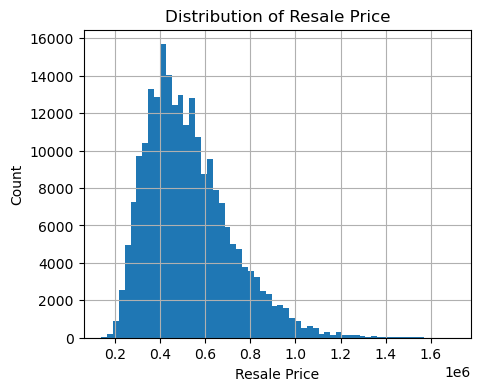

In [104]:
target_summary = pd.Series({
    "rows": len(df),
    "min_price": df["resale_price"].min(),
    "median_price": df["resale_price"].median(),
    "mean_price": df["resale_price"].mean(),
    "max_price": df["resale_price"].max(),
    "std_price": df["resale_price"].std(),
})
display(target_summary)

plt.figure(figsize=(5, 4))
plt.hist(df["resale_price"], bins=60)
plt.title("Distribution of Resale Price")
plt.xlabel("Resale Price")
plt.ylabel("Count")
plt.show()


## 2. Feature engineering


In [105]:
def parse_remaining_lease_to_months(text):
    if pd.isna(text):
        return np.nan

    text = str(text).strip().lower()
    years = 0
    months = 0

    import re
    y = re.search(r"(\d+)\s+year", text)
    m = re.search(r"(\d+)\s+month", text)

    if y:
        years = int(y.group(1))
    if m:
        months = int(m.group(1))

    return years * 12 + months

def parse_storey_mid(text):
    if pd.isna(text):
        return np.nan
    try:
        low, _, high = str(text).partition(" TO ")
        return (int(low) + int(high)) / 2
    except Exception:
        return np.nan

model_df_full = df.copy()

# time features
model_df_full["month"] = pd.to_datetime(model_df_full["month"], format="%Y-%m")
model_df_full["sale_year"] = model_df_full["month"].dt.year
model_df_full["sale_month_num"] = model_df_full["month"].dt.month
model_df_full["sale_quarter"] = model_df_full["month"].dt.quarter

# lease / age features
model_df_full["remaining_lease_months"] = model_df_full["remaining_lease"].apply(parse_remaining_lease_to_months)
model_df_full["property_age_at_sale"] = model_df_full["sale_year"] - model_df_full["lease_commence_date"]
model_df_full["lease_balance_years"] = model_df_full["remaining_lease_months"] / 12.0

# floor / area related
model_df_full["storey_mid"] = model_df_full["storey_range"].apply(parse_storey_mid)
model_df_full["price_per_sqm"] = model_df_full["resale_price"] / model_df_full["floor_area_sqm"]

# simplified location key
model_df_full["address"] = model_df_full["block"].astype(str) + " " + model_df_full["street_name"].astype(str)

# log target for optional analysis if needed
model_df_full["log_resale_price"] = np.log1p(model_df_full["resale_price"])

model_df_full.head()


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,longitude,sale_year,sale_month_num,sale_quarter,remaining_lease_months,property_age_at_sale,lease_balance_years,storey_mid,price_per_sqm,log_resale_price
0,2019-01-01,ANG MO KIO,4 ROOM,205,ANG MO KIO AVE 1,07 TO 09,98.0,New Generation,1977,57 years,...,103.843582,2019,1,1,684,42,57.000000,8.0,4163.265306,12.919025
1,2019-07-01,ANG MO KIO,4 ROOM,205,ANG MO KIO AVE 1,10 TO 12,98.0,New Generation,1977,56 years 06 months,...,103.843582,2019,7,3,678,42,56.500000,11.0,4132.653061,12.911645
2,2021-06-01,ANG MO KIO,4 ROOM,205,ANG MO KIO AVE 1,01 TO 03,98.0,New Generation,1977,54 years 08 months,...,103.843582,2021,6,2,656,44,54.666667,2.0,4253.061224,12.940364
3,2022-06-01,ANG MO KIO,4 ROOM,205,ANG MO KIO AVE 1,01 TO 03,98.0,New Generation,1977,53 years 08 months,...,103.843582,2022,6,2,644,45,53.666667,2.0,4775.510204,13.056226
4,2023-07-01,ANG MO KIO,4 ROOM,205,ANG MO KIO AVE 1,01 TO 03,98.0,New Generation,1977,52 years 07 months,...,103.843582,2023,7,3,631,46,52.583333,2.0,5255.102041,13.151924


In [106]:
engineered_numeric = [
    "floor_area_sqm",
    "lease_commence_date",
    "remaining_lease_months",
    "property_age_at_sale",
    "lease_balance_years",
    "storey_mid",
    "sale_year",
    "sale_month_num",
    "sale_quarter",
    "latitude",
    "longitude",
]

engineered_categorical = [
    "town",
    "flat_type",
    "flat_model",
    "street_name",
    # "storey_range",
]

keep_cols = engineered_numeric + engineered_categorical + ["resale_price", "price_per_sqm", "log_resale_price"]
model_df = model_df_full[keep_cols].copy()

print(model_df.shape)
model_df.head()


(226916, 18)


,floor_area_sqm,lease_commence_date,remaining_lease_months,property_age_at_sale,lease_balance_years,storey_mid,sale_year,sale_month_num,sale_quarter,latitude,longitude,town,flat_type,flat_model,street_name,resale_price,price_per_sqm,log_resale_price
0,98.0,1977,684,42,57.000000,8.0,2019,1,1,1.366941,103.843582,ANG MO KIO,4 ROOM,New Generation,ANG MO KIO AVE 1,408000.0,4163.265306,12.919025
1,98.0,1977,678,42,56.500000,11.0,2019,7,3,1.366941,103.843582,ANG MO KIO,4 ROOM,New Generation,ANG MO KIO AVE 1,405000.0,4132.653061,12.911645
2,98.0,1977,656,44,54.666667,2.0,2021,6,2,1.366941,103.843582,ANG MO KIO,4 ROOM,New Generation,ANG MO KIO AVE 1,416800.0,4253.061224,12.940364
3,98.0,1977,644,45,53.666667,2.0,2022,6,2,1.366941,103.843582,ANG MO KIO,4 ROOM,New Generation,ANG MO KIO AVE 1,468000.0,4775.510204,13.056226
4,98.0,1977,631,46,52.583333,2.0,2023,7,3,1.366941,103.843582,ANG MO KIO,4 ROOM,New Generation,ANG MO KIO AVE 1,515000.0,5255.102041,13.151924


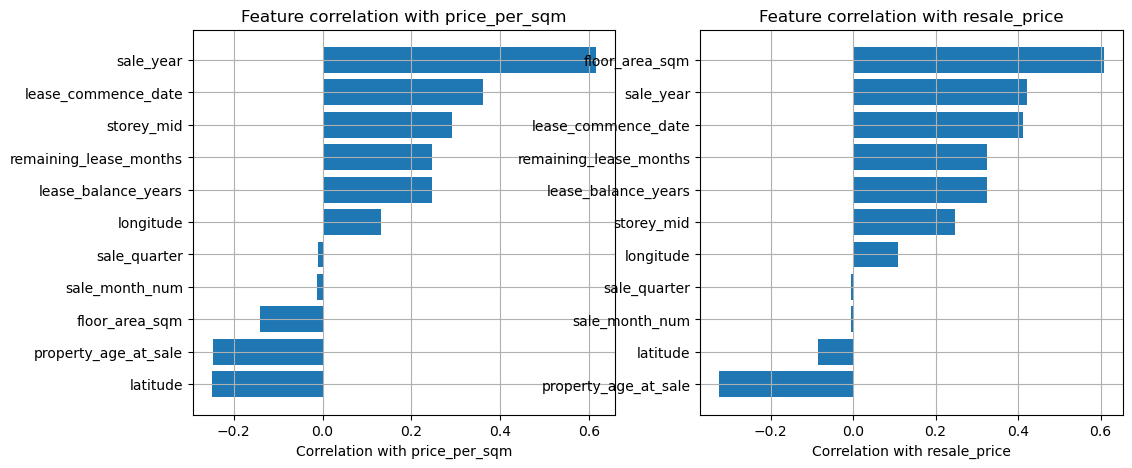

In [107]:
corr1 = model_df.select_dtypes(include=(['int32', 'int64', 'float64'])).corr('spearman')['price_per_sqm'].drop(["price_per_sqm", "resale_price", "log_resale_price"]).sort_values(ascending=True)
corr2 = model_df.select_dtypes(include=(['int32', 'int64', 'float64'])).corr('spearman')['resale_price'].drop(["price_per_sqm", "resale_price", "log_resale_price"]).sort_values(ascending=True)

f, (ax1, ax2) =  plt.subplots(nrows=1, ncols=2, figsize=(12,5))

ax1.barh(corr1.index, corr1.values)
ax1.set_xlabel("Correlation with price_per_sqm")
ax1.set_title("Feature correlation with price_per_sqm")

ax2.barh(corr2.index, corr2.values)
ax2.set_xlabel("Correlation with resale_price")
ax2.set_title("Feature correlation with resale_price")

plt.show()

## 3. Train, Validate, Test Data

In [108]:
X = model_df.drop(columns=["resale_price", "price_per_sqm", "log_resale_price"])
y = model_df["resale_price"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=RANDOM_STATE
)
# This gives about 70% train / 15% val / 15% test overall.

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (158835, 15) (158835,)
Validation: (34043, 15) (34043,)
Test: (34038, 15) (34038,)


## 4. Helper functions and preprocessors


In [109]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    nonzero_mask = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE_pct": mape,
    }

results = []
fitted_models = {}
predictions = {}

def add_result(model_name, fitted_model, X_eval, y_eval, fit_seconds=None, notes=None):
    pred = fitted_model.predict(X_eval)
    metrics = regression_metrics(y_eval, pred)
    metrics["Model"] = model_name
    if fit_seconds is not None:
        metrics["Fit_seconds"] = fit_seconds
    if notes is not None:
        metrics["Notes"] = notes
    results.append(metrics)
    fitted_models[model_name] = fitted_model
    predictions[model_name] = pred
    return pred, metrics

def sample_rows(X_df, y_series, max_rows, random_state=RANDOM_STATE):
    if (max_rows is None) or (len(X_df) <= max_rows):
        return X_df.copy(), y_series.copy()
    sampled_index = X_df.sample(n=max_rows, random_state=random_state).index
    return X_df.loc[sampled_index].copy(), y_series.loc[sampled_index].copy()

def evaluate_on_validation(pipeline, X_tr, y_tr, X_va, y_va):
    pipeline.fit(X_tr, y_tr)
    pred = pipeline.predict(X_va)
    return regression_metrics(y_va, pred)

def tune_with_progress(
    model_name,
    pipeline_builder,
    param_distributions,
    X_tr,
    y_tr,
    X_va,
    y_va,
    n_iter=8,
    sample_limit=None,
    random_state=RANDOM_STATE
):
    X_tr_use, y_tr_use = X_tr, y_tr
    if sample_limit is not None:
        X_tr_use, y_tr_use = sample_rows(X_tr, y_tr, sample_limit, random_state=random_state)

    sampled_params = list(ParameterSampler(param_distributions, n_iter=n_iter, random_state=random_state))

    tuning_rows = []
    best_score = np.inf
    best_params = None
    best_pipeline = None

    print(f"Tuning {model_name} on {len(X_tr_use):,} training rows and {len(X_va):,} validation rows")

    for params in tqdm(sampled_params, desc=f"{model_name} tuning"):
        pipeline = pipeline_builder(**params)
        start = time.time()
        metrics = evaluate_on_validation(pipeline, X_tr_use, y_tr_use, X_va, y_va)
        elapsed = time.time() - start

        row = {"fit_seconds": elapsed, **params, **metrics}
        tuning_rows.append(row)

        if metrics["RMSE"] < best_score:
            best_score = metrics["RMSE"]
            best_params = params
            best_pipeline = pipeline

    tuning_df = pd.DataFrame(tuning_rows).sort_values("RMSE").reset_index(drop=True)
    return best_params, tuning_df, best_pipeline

def fit_model_on_sample(pipeline, X_train_data, y_train_data, sample_limit=None, desc=None):
    X_fit, y_fit = sample_rows(X_train_data, y_train_data, sample_limit, random_state=RANDOM_STATE)
    if desc is not None:
        print(f"{desc}: fitting on {len(X_fit):,} rows")
    start = time.time()
    pipeline.fit(X_fit, y_fit)
    fit_seconds = time.time() - start
    return pipeline, fit_seconds, len(X_fit)

In [110]:
# General preprocessing
numeric_features = engineered_numeric
categorical_features = engineered_categorical

general_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
        ]), categorical_features),
    ]
)

# Tree-friendly preprocessing: impute numerics, one-hot categoricals, no numeric scaling needed
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
        ]), categorical_features),
    ]
)


## 5. Linear Regression


In [111]:
linear_model = Pipeline(steps=[
    ("preprocessor", general_preprocessor),
    ("model", LinearRegression())
])

start = time.time()
linear_model.fit(X_train_full, y_train_full)
linear_fit_seconds = time.time() - start

linear_pred, linear_metrics = add_result(
    "Linear Regression",
    linear_model,
    X_test,
    y_test,
    fit_seconds=linear_fit_seconds
)

linear_metrics

{'RMSE': np.float64(54747.330543853364),
 'MAE': 41276.815913018494,
 'R2': 0.9143578468725193,
 'MAPE_pct': np.float64(8.641104602262475),
 'Model': 'Linear Regression',
 'Fit_seconds': 5.091378211975098}

## 6. Polynomial Regression

To keep the feature space manageable, the polynomial expansion is applied only to the numeric features.


In [112]:
poly_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
        ]), categorical_features),
    ]
)

poly_model = Pipeline(steps=[
    ("preprocessor", poly_preprocessor),
    ("model", LinearRegression())
])

start = time.time()
poly_model.fit(X_train_full, y_train_full)
poly_fit_seconds = time.time() - start

poly_pred, poly_metrics = add_result(
    "Polynomial Regression",
    poly_model,
    X_test,
    y_test,
    fit_seconds=poly_fit_seconds
)

poly_metrics

{'RMSE': np.float64(43293.53405797439),
 'MAE': 32465.406711076917,
 'R2': 0.9464440461208288,
 'MAPE_pct': np.float64(6.533376413627308),
 'Model': 'Polynomial Regression',
 'Fit_seconds': 49.023353576660156}

## 7. Random Forest

### Speed strategy
A large Random Forest on the full dataset can take a long time locally, especially with one-hot encoded street names and geospatial features.

This version reduces runtime by:
- tuning on a **sample** of the training set
- using a **small focused parameter grid**
- limiting the final Random Forest fit to a **larger sample** rather than the full training set
- keeping `n_estimators` moderate
- showing a **progress bar**

In [113]:
def build_rf_pipeline(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
):
    return Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

rf_param_distributions = {
    "n_estimators": [60, 100, 140],
    "max_depth": [14, 20, 28],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5],
}

rf_best_params, rf_tuning_df, _ = tune_with_progress(
    model_name="Random Forest",
    pipeline_builder=build_rf_pipeline,
    param_distributions=rf_param_distributions,
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    y_va=y_val,
    n_iter=6,
    sample_limit=30000
)

display(rf_tuning_df.head(10))

print("Best RF params:", rf_best_params)

best_rf_model = build_rf_pipeline(**rf_best_params)

RF_FINAL_SAMPLE = 60000
best_rf_model, rf_fit_seconds, rf_rows_used = fit_model_on_sample(
    best_rf_model,
    X_train_full,
    y_train_full,
    sample_limit=RF_FINAL_SAMPLE,
    desc="Random Forest"
)

rf_pred, rf_metrics = add_result(
    "Random Forest",
    best_rf_model,
    X_test,
    y_test,
    fit_seconds=rf_fit_seconds,
    notes=f"trained on {rf_rows_used:,} sampled rows"
)

rf_metrics

Tuning Random Forest on 30,000 training rows and 34,043 validation rows


Random Forest tuning:   0%|          | 0/6 [00:00<?, ?it/s]

,fit_seconds,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,RMSE,MAE,R2,MAPE_pct
0,23.476624,100,5,2,0.5,20,39202.021670,26807.269079,0.956681,5.094480
1,21.491098,140,5,4,0.5,28,40998.328093,27819.395127,0.952620,5.260795
2,29.553474,140,2,1,0.5,14,42818.347670,30425.159825,0.948320,5.829057
3,14.861656,100,2,1,sqrt,28,48055.828895,34465.065069,0.934904,6.734810
4,7.110933,100,2,1,sqrt,20,62415.847530,46305.623387,0.890188,9.242893
5,4.076265,140,5,4,sqrt,28,62831.026403,44848.181779,0.888722,8.843621


Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 20}
Random Forest: fitting on 60,000 rows


{'RMSE': np.float64(34048.655253209094),
 'MAE': 23763.17454047791,
 'R2': 0.966874563505402,
 'MAPE_pct': np.float64(4.56386627610503),
 'Model': 'Random Forest',
 'Fit_seconds': 73.81847834587097,
 'Notes': 'trained on 60,000 sampled rows'}

## 8. k-Nearest Neighbors

In [114]:

def build_knn_pipeline(
    n_neighbors=20,
    weights="distance",
    p=2,
):
    return Pipeline(steps=[
        ("preprocessor", general_preprocessor),
        ("model", KNeighborsRegressor(
            n_neighbors=n_neighbors,
            weights=weights,
            p=p,
            n_jobs=-1
        ))
    ])

knn_param_distributions = {
    "n_neighbors": [5, 10, 20, 30, 40],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}

knn_best_params, knn_tuning_df, _ = tune_with_progress(
    model_name="KNN",
    pipeline_builder=build_knn_pipeline,
    param_distributions=knn_param_distributions,
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    y_va=y_val,
    n_iter=8,
    sample_limit=40000
)

display(knn_tuning_df.head(10))

best_knn_model = build_knn_pipeline(**knn_best_params)

start = time.time()
best_knn_model.fit(X_train_full, y_train_full)
knn_fit_seconds = time.time() - start

knn_pred, knn_metrics = add_result(
    "k-Nearest Neighbors",
    best_knn_model,
    X_test,
    y_test,
    fit_seconds=knn_fit_seconds
)

knn_metrics

Tuning KNN on 40,000 training rows and 34,043 validation rows


KNN tuning:   0%|          | 0/8 [00:00<?, ?it/s]

,fit_seconds,weights,p,n_neighbors,RMSE,MAE,R2,MAPE_pct
0,30.534710,distance,1,5,48527.232841,34412.397699,0.933621,6.625269
1,44.814048,distance,2,5,48660.989141,34529.445802,0.933255,6.638563
2,29.317238,distance,1,10,49421.254449,35057.992946,0.931153,6.749196
3,30.617735,uniform,1,5,51160.595974,36624.888880,0.926221,7.046308
4,40.816738,distance,2,20,52332.018057,36649.649806,0.922804,6.998297
5,40.301136,distance,2,30,54844.215111,38314.090523,0.915215,7.310828
6,30.102019,uniform,1,20,57849.704617,41417.834743,0.905667,7.973019
7,31.558323,distance,1,40,58357.035536,41364.730746,0.904006,7.962995


{'RMSE': np.float64(36477.58893853192),
 'MAE': 25958.08811001894,
 'R2': 0.9619798407728425,
 'MAPE_pct': np.float64(5.033919330189282),
 'Model': 'k-Nearest Neighbors',
 'Fit_seconds': 2.0971925258636475}

## 9. Neural Network (MLPRegressor)

`MLPRegressor` can also be slow because one-hot encoding creates a very wide feature matrix.  
To keep runtime manageable, this version:
- uses a smaller training sample for tuning
- uses compact hidden-layer configurations
- reduces `max_iter`
- keeps `early_stopping=True`
- also fits the final model on a sampled training set

In [115]:
def build_mlp_pipeline(
    hidden_layer_sizes=(64, 32),
    alpha=0.001,
    learning_rate_init=0.003,
):
    return Pipeline(steps=[
        ("preprocessor", general_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            alpha=alpha,
            learning_rate_init=learning_rate_init,
            max_iter=120,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=8,
            random_state=RANDOM_STATE
        ))
    ])

mlp_param_distributions = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "alpha": [1e-4, 1e-3, 1e-2],
    "learning_rate_init": [0.001, 0.003]
}

mlp_best_params, mlp_tuning_df, _ = tune_with_progress(
    model_name="MLP",
    pipeline_builder=build_mlp_pipeline,
    param_distributions=mlp_param_distributions,
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    y_va=y_val,
    n_iter=5,
    sample_limit=25000
)

display(mlp_tuning_df.head(10))

print("Best MLP params:", mlp_best_params)

best_mlp_model = build_mlp_pipeline(**mlp_best_params)

MLP_FINAL_SAMPLE = 40000
best_mlp_model, mlp_fit_seconds, mlp_rows_used = fit_model_on_sample(
    best_mlp_model,
    X_train_full,
    y_train_full,
    sample_limit=MLP_FINAL_SAMPLE,
    desc="MLP"
)

mlp_pred, mlp_metrics = add_result(
    "Neural Network (MLP)",
    best_mlp_model,
    X_test,
    y_test,
    fit_seconds=mlp_fit_seconds,
    notes=f"trained on {mlp_rows_used:,} sampled rows"
)

mlp_metrics

Tuning MLP on 25,000 training rows and 34,043 validation rows


MLP tuning:   0%|          | 0/5 [00:00<?, ?it/s]

,fit_seconds,learning_rate_init,hidden_layer_sizes,alpha,RMSE,MAE,R2,MAPE_pct
0,54.605048,0.003,"(64, 32)",0.0001,43386.242746,31842.815794,0.946940,6.330436
1,29.570258,0.003,"(64,)",0.0001,208765.222074,173757.568403,-0.228501,32.637823
2,20.828368,0.003,"(32,)",0.0001,422651.126632,392832.288137,-4.035277,74.150804
3,28.710916,0.001,"(64,)",0.0010,512414.056411,481577.421707,-6.401187,91.249741
4,19.008183,0.001,"(32,)",0.0001,545691.354007,513506.122822,-7.393700,97.258029


Best MLP params: {'learning_rate_init': 0.003, 'hidden_layer_sizes': (64, 32), 'alpha': 0.0001}
MLP: fitting on 40,000 rows


{'RMSE': np.float64(36844.98832011487),
 'MAE': 26403.33788372595,
 'R2': 0.9612101118172814,
 'MAPE_pct': np.float64(5.126252239501136),
 'Model': 'Neural Network (MLP)',
 'Fit_seconds': 98.50278186798096,
 'Notes': 'trained on 40,000 sampled rows'}

## 10. XGBoost


In [116]:
def build_xgb_pipeline(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
):
    return Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

xgb_param_distributions = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

xgb_best_params, xgb_tuning_df, _ = tune_with_progress(
    model_name="XGBoost",
    pipeline_builder=build_xgb_pipeline,
    param_distributions=xgb_param_distributions,
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    y_va=y_val,
    n_iter=8,
    sample_limit=80000
)

display(xgb_tuning_df.head(10))

best_xgb_model = build_xgb_pipeline(**xgb_best_params)

start = time.time()
best_xgb_model.fit(X_train_full, y_train_full)
xgb_fit_seconds = time.time() - start

xgb_pred, xgb_metrics = add_result(
    "XGBoost",
    best_xgb_model,
    X_test,
    y_test,
    fit_seconds=xgb_fit_seconds
)

display(xgb_metrics)

Tuning XGBoost on 80,000 training rows and 34,043 validation rows


XGBoost tuning:   0%|          | 0/8 [00:00<?, ?it/s]

,fit_seconds,subsample,n_estimators,max_depth,learning_rate,colsample_bytree,RMSE,MAE,R2,MAPE_pct
0,4.250314,0.7,500,6,0.10,0.8,31265.983763,22702.656156,0.972445,4.452028
1,3.917269,0.8,300,8,0.10,1.0,31289.477322,22536.966912,0.972403,4.391327
2,4.474688,0.8,500,6,0.10,1.0,31656.401586,22968.193999,0.971752,4.496549
3,3.664924,1.0,500,6,0.10,0.8,31725.472579,22962.872027,0.971629,4.486446
4,4.853905,1.0,500,8,0.05,1.0,32081.605282,23119.900468,0.970988,4.505707
5,6.011519,0.7,500,8,0.03,0.7,32572.048025,23548.584322,0.970095,4.606735
6,3.209570,0.8,300,6,0.03,1.0,40118.476027,29255.631602,0.954632,5.693321
7,3.574413,0.7,500,4,0.03,0.7,43210.077713,31546.146451,0.947370,6.111954


{'RMSE': np.float64(30784.220799223174),
 'MAE': 22455.960697657767,
 'R2': 0.9729219109596602,
 'MAPE_pct': np.float64(4.4027286686151985),
 'Model': 'XGBoost',
 'Fit_seconds': 8.80082106590271}

## 11. LightGBM


In [117]:
def build_lgbm_pipeline(
    n_estimators=400,
    num_leaves=31,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
):
    return Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", LGBMRegressor(
            n_estimators=n_estimators,
            num_leaves=num_leaves,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

lgbm_param_distributions = {
    "n_estimators": [250, 400, 600],
    "num_leaves": [31, 63, 127],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

lgbm_best_params, lgbm_tuning_df, _ = tune_with_progress(
    model_name="LightGBM",
    pipeline_builder=build_lgbm_pipeline,
    param_distributions=lgbm_param_distributions,
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    y_va=y_val,
    n_iter=8,
    sample_limit=80000
)

display(lgbm_tuning_df.head(10))

best_lgbm_model = build_lgbm_pipeline(**lgbm_best_params)

start = time.time()
best_lgbm_model.fit(X_train_full, y_train_full)
lgbm_fit_seconds = time.time() - start

lgbm_pred, lgbm_metrics = add_result(
    "LightGBM",
    best_lgbm_model,
    X_test,
    y_test,
    fit_seconds=lgbm_fit_seconds
)

display(lgbm_metrics)

Tuning LightGBM on 80,000 training rows and 34,043 validation rows


LightGBM tuning:   0%|          | 0/8 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005627 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2454
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 570
[LightGBM] [Info] Start training from score 527894.811845
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2454
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 570
[LightGBM] [Info] Start training from score 527894.811845
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [In

,fit_seconds,subsample,num_leaves,n_estimators,learning_rate,colsample_bytree,RMSE,MAE,R2,MAPE_pct
0,5.766589,1.0,127,400,0.10,0.8,27659.665884,19600.151414,0.978435,3.827025
1,5.882643,0.7,127,400,0.10,0.8,27659.665884,19600.151414,0.978435,3.827025
2,5.931145,0.8,127,400,0.10,1.0,27849.619642,19723.198045,0.978138,3.842035
3,6.519528,0.8,63,600,0.10,1.0,27888.951312,19885.307590,0.978076,3.886847
4,8.904334,1.0,127,600,0.05,1.0,27908.800540,19784.360849,0.978045,3.861888
5,8.850118,0.7,127,600,0.03,0.7,28010.730038,19904.083632,0.977884,3.895417
6,4.737806,0.7,127,250,0.03,0.7,31714.533285,22725.860338,0.971649,4.449889
7,5.524779,0.8,63,400,0.03,1.0,31758.435837,22854.649757,0.971570,4.465467


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012232 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2562
[LightGBM] [Info] Number of data points in the train set: 192878, number of used features: 620
[LightGBM] [Info] Start training from score 527262.073034


{'RMSE': np.float64(26246.690776596824),
 'MAE': 18695.166478303505,
 'R2': 0.9803161162878058,
 'MAPE_pct': np.float64(3.6631433415988623),
 'Model': 'LightGBM',
 'Fit_seconds': 8.282470464706421}

## 12. Model comparison


In [118]:
results_df = pd.DataFrame(results)

if len(results_df) > 0:
    ordered_cols = ["Model", "RMSE", "MAE", "R2", "MAPE_pct", "Fit_seconds", "Notes"]
    existing_cols = [col for col in ordered_cols if col in results_df.columns]
    results_df = results_df[existing_cols].sort_values("RMSE").reset_index(drop=True)

display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print("Best model based on lowest test RMSE:", best_model_name)

,Model,RMSE,MAE,R2,MAPE_pct,Fit_seconds,Notes
0,LightGBM,26246.690777,18695.166478,0.980316,3.663143,8.282470,NaN
1,XGBoost,30784.220799,22455.960698,0.972922,4.402729,8.800821,NaN
2,Random Forest,34048.655253,23763.174540,0.966875,4.563866,73.818478,"trained on 60,000 sampled rows"
3,k-Nearest Neighbors,36477.588939,25958.088110,0.961980,5.033919,2.097193,NaN
4,Neural Network (MLP),36844.988320,26403.337884,0.961210,5.126252,98.502782,"trained on 40,000 sampled rows"
5,Polynomial Regression,43293.534058,32465.406711,0.946444,6.533376,49.023354,NaN
6,Linear Regression,54747.330544,41276.815913,0.914358,8.641105,5.091378,NaN


Best model based on lowest test RMSE: LightGBM


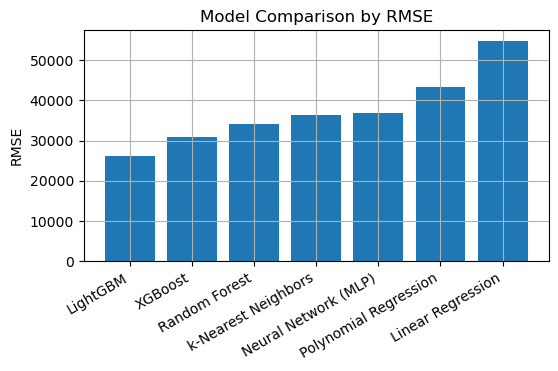

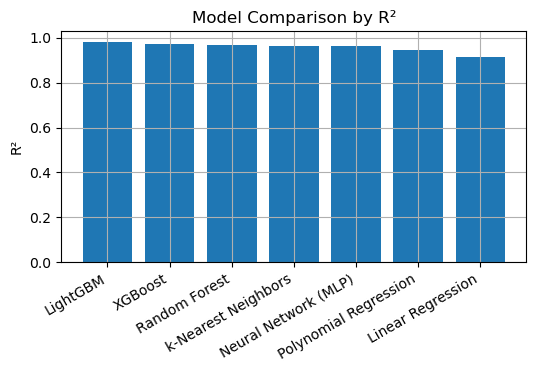

In [119]:

plt.figure(figsize=(6, 3))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=30, ha="right")
plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(6, 3))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=30, ha="right")
plt.title("Model Comparison by R²")
plt.ylabel("R²")
plt.show()


## 13. Actual vs predicted plots


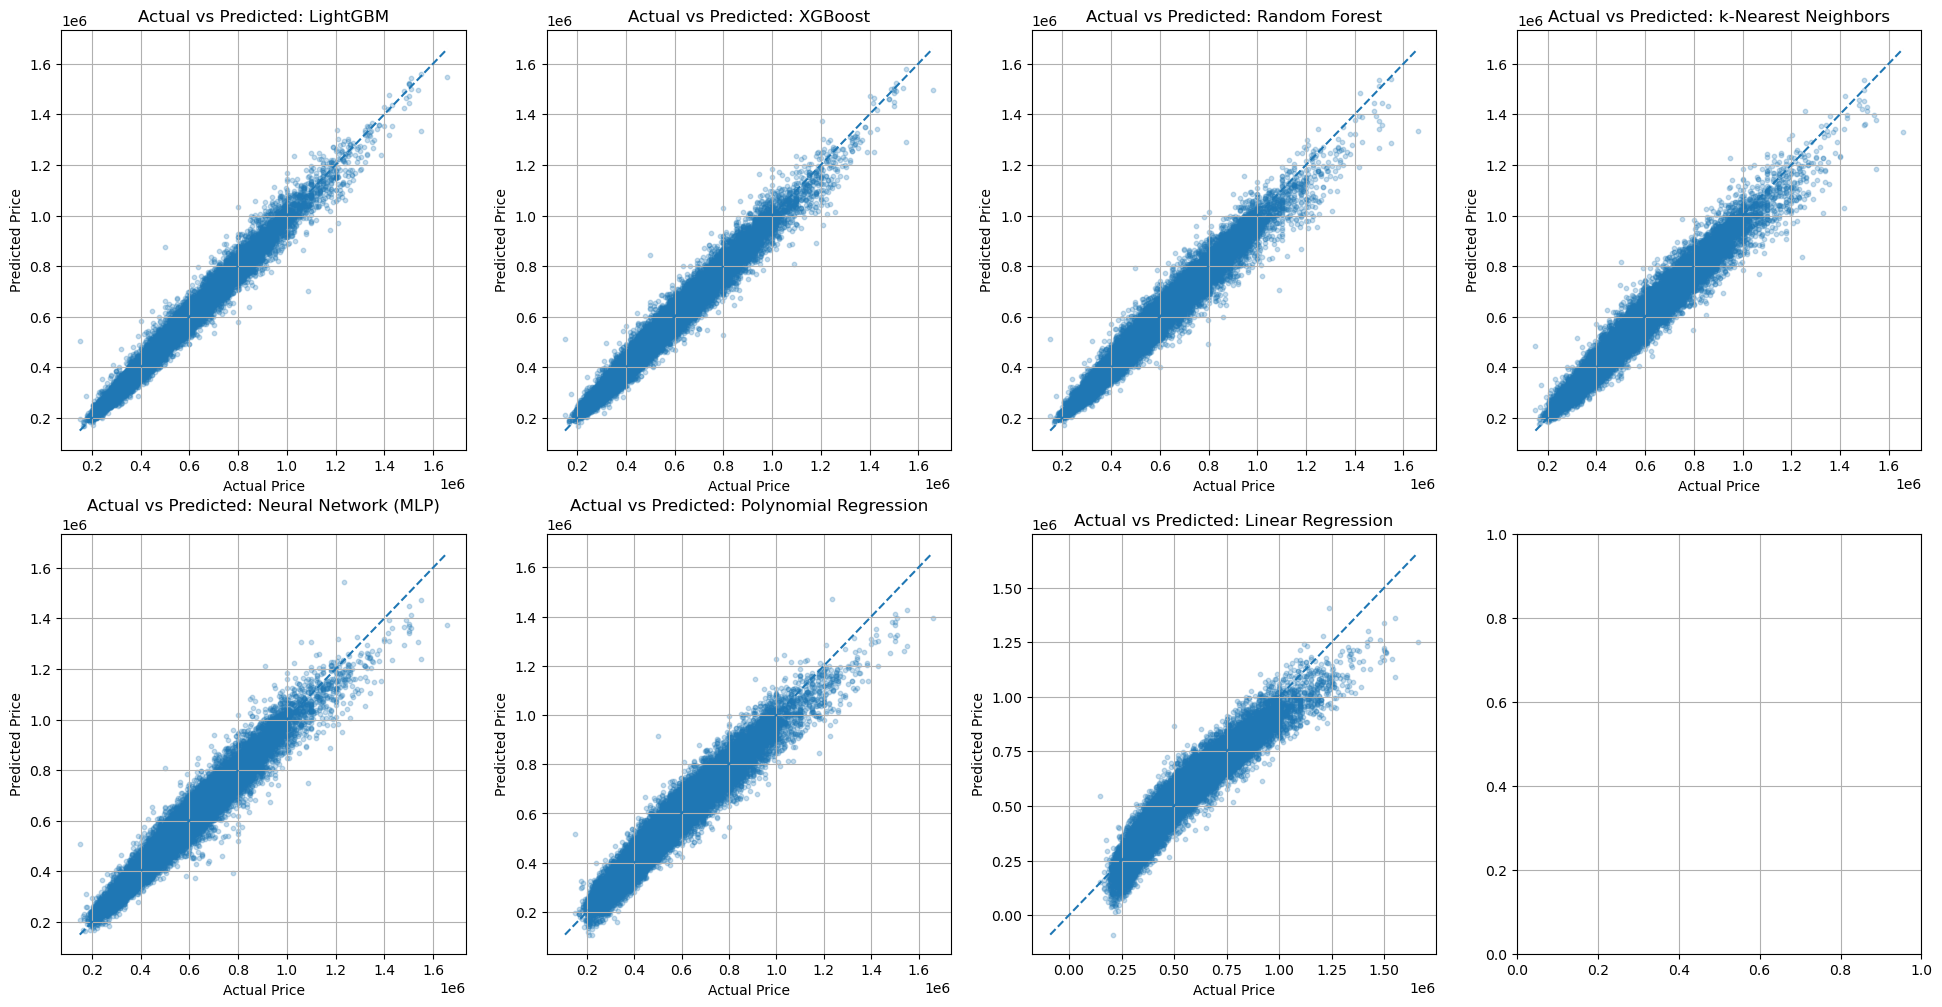

In [120]:
f, ([ax1, ax2, ax3, ax4], [ax5, ax6, ax7, ax8]) =  plt.subplots(2, 4, figsize=(24,12))

for i in range(0,len(results_df["Model"])):
    model_name = results_df["Model"][i]
    axes =[ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8][i]
    
    pred = predictions[model_name]
    axes.scatter(y_test, pred, alpha=0.25, s=10)
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    axes.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    axes.set_title(f"Actual vs Predicted: {model_name}")
    axes.set_xlabel("Actual Price")
    axes.set_ylabel("Predicted Price")

plt.show()


## 14. Feature importance and SHAP

This section:
1. finds the best available **tree-based** model among Random Forest / XGBoost / LightGBM  
2. shows built-in feature importance if available  
3. tries to compute **SHAP** values on a sample


In [121]:
tree_model_candidates = [name for name in results_df["Model"] if name in ["LightGBM", "XGBoost", "Random Forest"]]
best_tree_model_name = tree_model_candidates[0] if len(tree_model_candidates) > 0 else None
print("Best tree-based model:", best_tree_model_name)

Best tree-based model: LightGBM


,feature,importance
2,num__remaining_lease_months,5853
0,num__floor_area_sqm,5682
9,num__latitude,5577
10,num__longitude,4910
6,num__sale_year,3017
5,num__storey_mid,2751
1,num__lease_commence_date,2394
7,num__sale_month_num,2323
3,num__property_age_at_sale,1276
4,num__lease_balance_years,1055


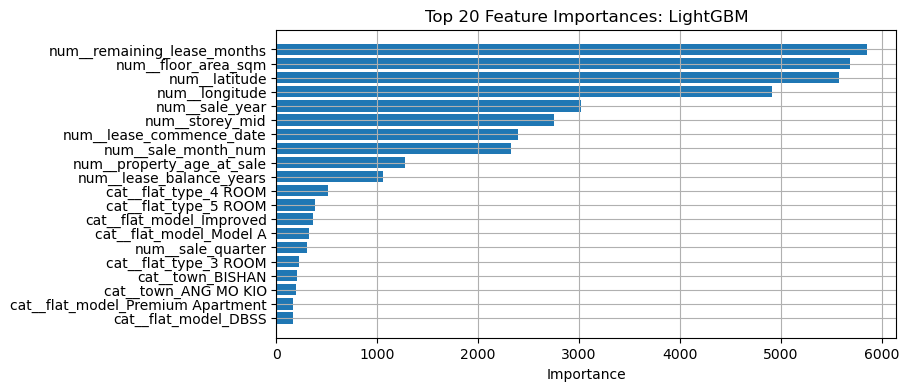

In [122]:
best_tree_model = fitted_models[best_tree_model_name]
tree_pre = best_tree_model.named_steps["preprocessor"]
tree_est = best_tree_model.named_steps["model"]

feature_names = tree_pre.get_feature_names_out()

if hasattr(tree_est, "feature_importances_"):
    feature_importances = pd.DataFrame({
        "feature": feature_names,
        "importance": tree_est.feature_importances_
    }).sort_values("importance", ascending=False)

    display(feature_importances.head(20))

    top_n = 20
    top_feat = feature_importances.head(top_n).sort_values("importance")
    plt.figure(figsize=(8, 4))
    plt.barh(top_feat["feature"], top_feat["importance"])
    plt.title(f"Top {top_n} Feature Importances: {best_tree_model_name}")
    plt.xlabel("Importance")
    plt.show()


 99%|===================| 1185/1200 [01:13<00:00]        

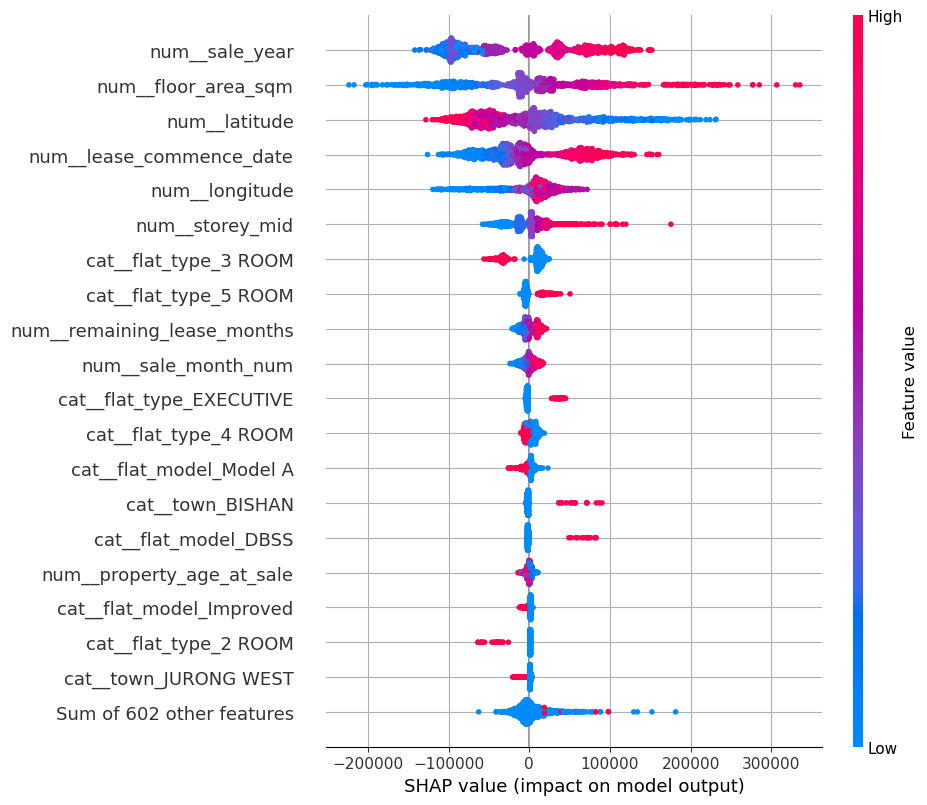

In [123]:
best_tree_model = fitted_models[best_tree_model_name]
tree_pre = best_tree_model.named_steps["preprocessor"]
tree_est = best_tree_model.named_steps["model"]

X_shap_sample, y_shap_sample = sample_rows(X_test, y_test, max_rows=1200, random_state=RANDOM_STATE)
X_shap_transformed = tree_pre.transform(X_shap_sample)

if hasattr(X_shap_transformed, "toarray"):
    # Keep sample moderate to avoid excessive memory use
    X_shap_dense = X_shap_transformed.toarray()
else:
    X_shap_dense = X_shap_transformed

try:
    explainer = shap.Explainer(tree_est, X_shap_dense, feature_names=tree_pre.get_feature_names_out())
    shap_values = explainer(X_shap_dense)

    shap.plots.beeswarm(shap_values, max_display=20)
except Exception as e:
    print("SHAP calculation failed for this model/environment.")
    print("Details:", e)


## 15. Singapore geospatial maps and market heatmaps

Because latitude / longitude are now available, this section adds map-style visualizations of Singapore.

It includes:
- a **transaction density map** using hexbin
- a **median resale price map** using spatial grid cells
- the earlier **town / year** and **town / flat type** market heatmaps for comparison

These are static matplotlib plots, so they run without requiring extra mapping libraries.

In [124]:
def percentile_clip(series: pd.Series, low: float = 0.1, high: float = 0.9) -> tuple[float, float]:
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return (np.nan, np.nan)
    return (float(s.quantile(low)), float(s.quantile(high)))

def plot_metric_map(
    gdf: gpd.GeoDataFrame,
    metric_col: str,
    title: str,
    # output_pdf: Path,
    cmap: str = "viridis",
    clip_quantiles: tuple[float, float] = (0.02, 0.98),
    center_zero: bool = False,
    marker_size: int = 22,
    legend_label: str | None = None,
):
    data = gdf.dropna(subset=[metric_col]).copy()
    if data.empty:
        raise ValueError(f"No data available for {metric_col}")

    q_low, q_high = percentile_clip(data[metric_col], *clip_quantiles)
    data["metric_clipped"] = data[metric_col].clip(q_low, q_high)

    data_3857 = data.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(9, 10))

    if center_zero:
        bound = max(abs(q_low), abs(q_high))
        norm = TwoSlopeNorm(vmin=-bound, vcenter=0.0, vmax=bound)
    else:
        norm = Normalize(vmin=q_low, vmax=q_high)

    data_3857.plot(
        ax=ax,
        column="metric_clipped",
        cmap=cmap,
        markersize=marker_size,
        alpha=0.9,
        legend=True,
        norm=norm,
        legend_kwds={"shrink": 0.35, "label": legend_label or metric_col},
        zorder=3,
    )
    
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution=False)

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

    # Zoom to the buildings with a small margin
    xmin, ymin, xmax, ymax = data_3857.total_bounds
    xpad = (xmax - xmin) * 0.05
    ypad = (ymax - ymin) * 0.05
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    plt.tight_layout()
    # plt.savefig(output_pdf, bbox_inches="tight")
    plt.show()
       


In [125]:
def build_geodf(df: pd.DataFrame) -> gpd.GeoDataFrame:
    out = df.copy()
    geometry = [Point(xy) for xy in zip(out["longitude"], out["latitude"])]
    gdf = gpd.GeoDataFrame(out, geometry=geometry, crs="EPSG:4326")
    return gdf

building_metrics_year = (
    model_df_full
    .groupby(["sale_year", "address"], as_index=False)
    .agg(
        median_psm=("price_per_sqm", "median"),
        txn_count=("price_per_sqm", "size"),
        latitude=("latitude", "median"),
        longitude=("longitude", "median"),
        address=("address", "first"),
        town=("town", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
    )
)

building_metrics = (
    model_df_full
    .groupby(["address"], as_index=False)
    .agg(
        median_psm=("price_per_sqm", "median"),
        txn_count=("price_per_sqm", "size"),
        latitude=("latitude", "median"),
        longitude=("longitude", "median"),
        address=("address", "first"),
        town=("town", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
    )
)

gdf_buildings_year = build_geodf(building_metrics_year)
gdf_buildings = build_geodf(building_metrics)

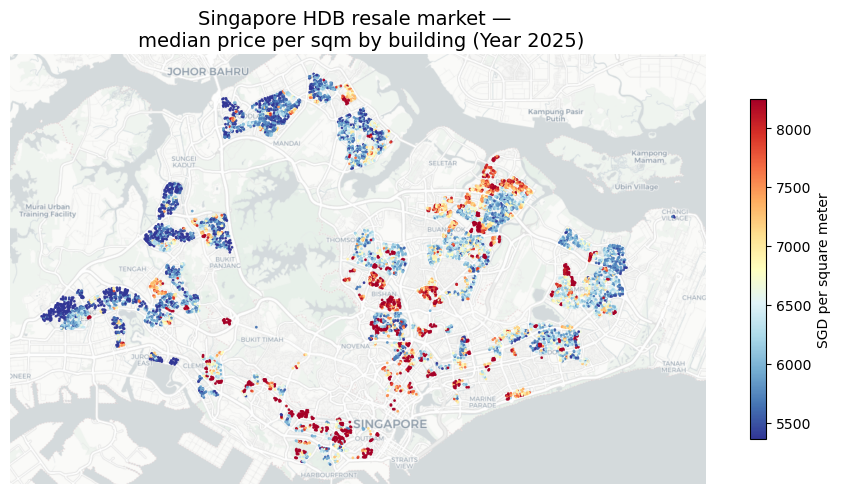

In [126]:
plot_metric_map(
    gdf_buildings_year[gdf_buildings_year.sale_year==2025],
    metric_col="median_psm",
    title="Singapore HDB resale market — \n median price per sqm by building (Year 2025)",
    cmap="RdYlBu_r",
    clip_quantiles=(0.10, 0.90),
    center_zero=False,
    marker_size=1,
    legend_label="SGD per square meter",
)

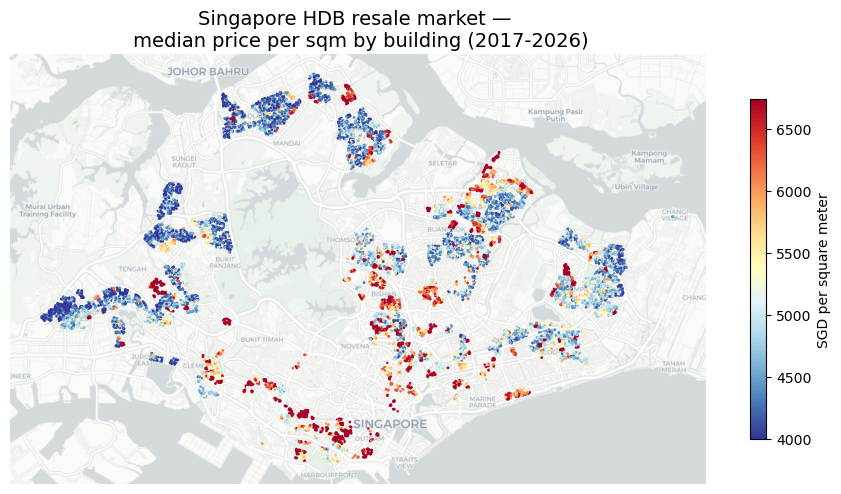

In [127]:
plot_metric_map(
    gdf_buildings,
    metric_col="median_psm",
    title="Singapore HDB resale market — \n median price per sqm by building (2017-2026)",
    cmap="RdYlBu_r",
    clip_quantiles=(0.10, 0.90),
    center_zero=False,
    marker_size=1,
    legend_label="SGD per square meter",
)

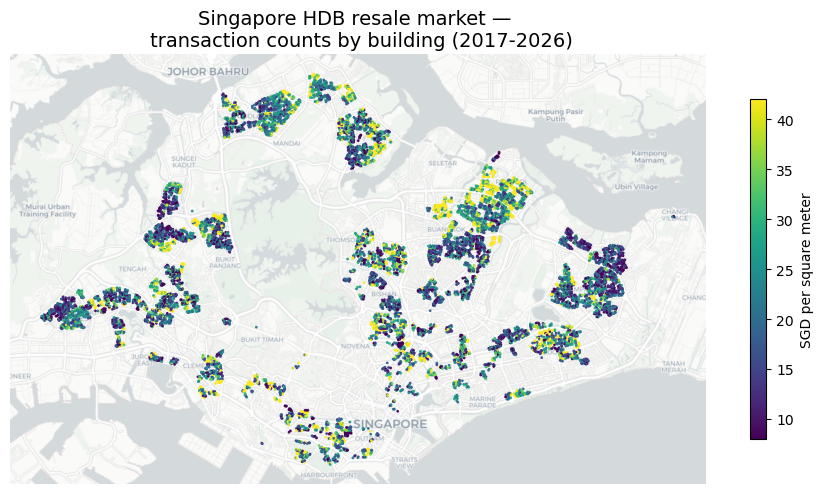

In [128]:
plot_metric_map(
    gdf_buildings,
    metric_col="txn_count",
    title="Singapore HDB resale market — \n transaction counts by building (2017-2026)",
    clip_quantiles=(0.10, 0.90),
    center_zero=False,
    marker_size=1,
    legend_label="SGD per square meter",
)


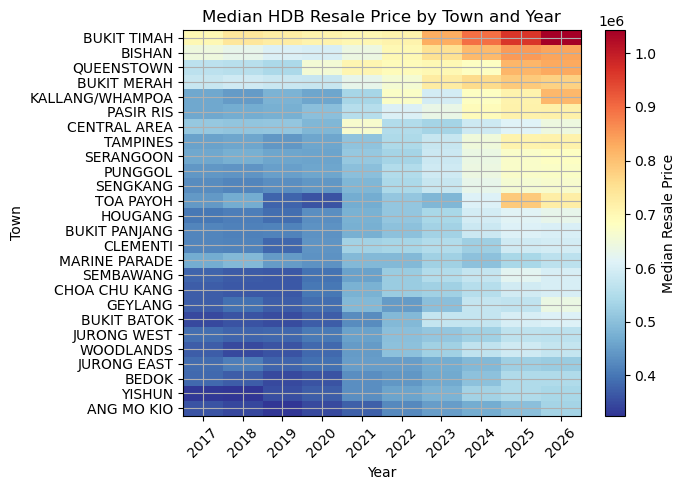

In [129]:
# Median resale price by town and sale year
heatmap_year = (
    df.assign(sale_year=pd.to_datetime(df["month"]).dt.year)
      .groupby(["town", "sale_year"])["resale_price"]
      .median()
      .unstack()
)

heatmap_year = heatmap_year.loc[heatmap_year.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_year, aspect="auto", cmap='RdYlBu_r')
plt.colorbar(label="Median Resale Price")
plt.yticks(range(len(heatmap_year.index)), heatmap_year.index)
plt.xticks(range(len(heatmap_year.columns)), heatmap_year.columns, rotation=45)
plt.title("Median HDB Resale Price by Town and Year")
plt.xlabel("Year")
plt.ylabel("Town")
plt.tight_layout()
plt.show()


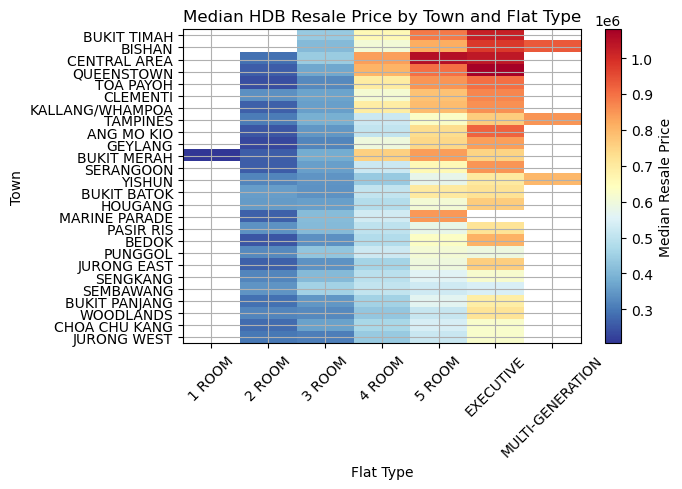

In [130]:

# Median resale price by town and flat type
heatmap_flat = (
    df.groupby(["town", "flat_type"])["resale_price"]
      .median()
      .unstack()
)

heatmap_flat = heatmap_flat.loc[heatmap_flat.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_flat, aspect="auto", cmap="RdYlBu_r")
plt.colorbar(label="Median Resale Price")
plt.yticks(range(len(heatmap_flat.index)), heatmap_flat.index)
plt.xticks(range(len(heatmap_flat.columns)), heatmap_flat.columns, rotation=45)
plt.title("Median HDB Resale Price by Town and Flat Type")
plt.xlabel("Flat Type")
plt.ylabel("Town")
plt.tight_layout()
plt.show()

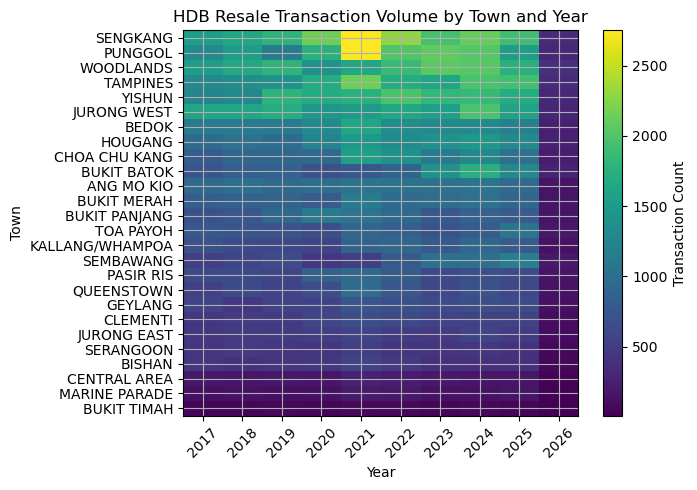

In [131]:
# Transaction volume by town and year
volume_heatmap = (
    df.assign(sale_year=pd.to_datetime(df["month"]).dt.year)
      .groupby(["town", "sale_year"])
      .size()
      .unstack(fill_value=0)
)

volume_heatmap = volume_heatmap.loc[volume_heatmap.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(7, 5))
plt.imshow(volume_heatmap, aspect="auto")
plt.colorbar(label="Transaction Count")
plt.yticks(range(len(volume_heatmap.index)), volume_heatmap.index)
plt.xticks(range(len(volume_heatmap.columns)), volume_heatmap.columns, rotation=45)
plt.title("HDB Resale Transaction Volume by Town and Year")
plt.xlabel("Year")
plt.ylabel("Town")
plt.tight_layout()
plt.show()


## 16. Dimension reduction for visualization

To avoid overcrowding, the visualization uses only a sample of the dataset.


In [132]:

sample_n = min(3000, len(model_df))
viz_df = model_df.sample(sample_n, random_state=RANDOM_STATE).copy()

X_viz = viz_df.drop(columns=["resale_price", "price_per_sqm", "log_resale_price"])
y_viz = viz_df["resale_price"]

viz_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
        ]), categorical_features),
    ]
)

X_viz_transformed = viz_preprocessor.fit_transform(X_viz)

if hasattr(X_viz_transformed, "toarray"):
    X_viz_dense = X_viz_transformed.toarray()
else:
    X_viz_dense = X_viz_transformed

print("Visualization sample size:", len(viz_df))
print("Transformed visualization matrix shape:", X_viz_dense.shape)


Visualization sample size: 3000
Transformed visualization matrix shape: (3000, 73)


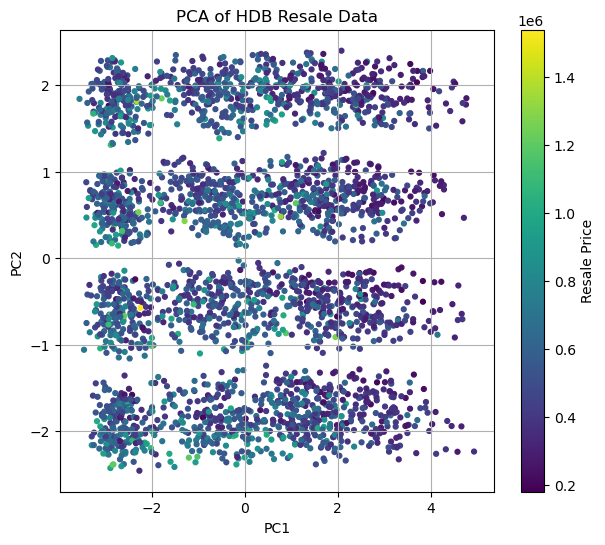

Explained variance ratio: [0.31905106 0.14530223]


In [133]:

# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_viz_dense)

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_viz, s=12)
plt.colorbar(sc, label="Resale Price")
plt.title("PCA of HDB Resale Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


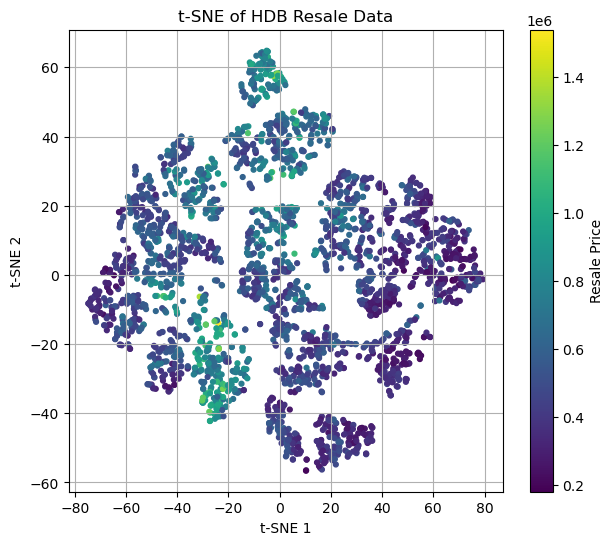

In [134]:

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE
)
X_tsne = tsne.fit_transform(X_viz_dense)

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_viz, s=12)
plt.colorbar(sc, label="Resale Price")
plt.title("t-SNE of HDB Resale Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


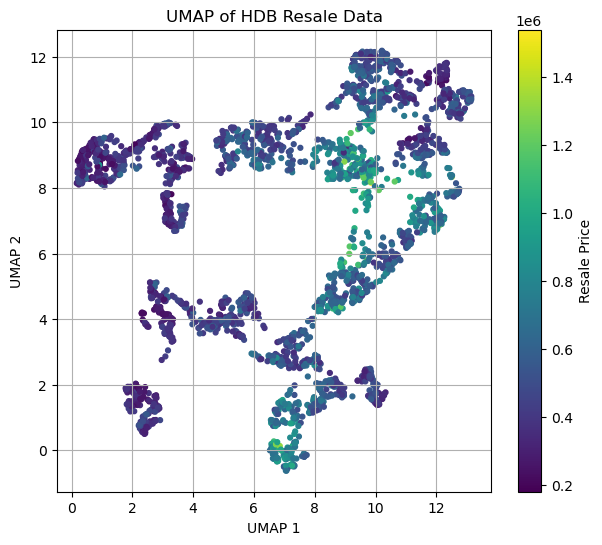

In [135]:

# UMAP
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_viz_dense)

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_viz, s=12)
    plt.colorbar(sc, label="Resale Price")
    plt.title("UMAP of HDB Resale Data")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()
except Exception as e:
    print("UMAP is not installed or failed to run.")
    print("Install with: %pip install umap-learn")
    print("Details:", e)


## 17. Final summary


In [136]:
display(results_df)

print("Best model:", best_model_name)
print()
print("Interpretation tips:")
print("- Lower RMSE / MAE is better.")
print("- Higher R² is better.")
print("- Random Forest and MLP in this notebook are intentionally trained on sampled rows to keep runtime practical.")
print("- If you want the absolute best accuracy later, you can increase RF_FINAL_SAMPLE and MLP_FINAL_SAMPLE gradually.")
print("- The geospatial maps use the geocoded latitude / longitude columns you added.")
print("- Tree boosting models often outperform plain linear models on housing data if the package is available.")
print("- KNN can also be slow when predicting on very large sets.")

,Model,RMSE,MAE,R2,MAPE_pct,Fit_seconds,Notes
0,LightGBM,26246.690777,18695.166478,0.980316,3.663143,8.282470,NaN
1,XGBoost,30784.220799,22455.960698,0.972922,4.402729,8.800821,NaN
2,Random Forest,34048.655253,23763.174540,0.966875,4.563866,73.818478,"trained on 60,000 sampled rows"
3,k-Nearest Neighbors,36477.588939,25958.088110,0.961980,5.033919,2.097193,NaN
4,Neural Network (MLP),36844.988320,26403.337884,0.961210,5.126252,98.502782,"trained on 40,000 sampled rows"
5,Polynomial Regression,43293.534058,32465.406711,0.946444,6.533376,49.023354,NaN
6,Linear Regression,54747.330544,41276.815913,0.914358,8.641105,5.091378,NaN


Best model: LightGBM

Interpretation tips:
- Lower RMSE / MAE is better.
- Higher R² is better.
- Random Forest and MLP in this notebook are intentionally trained on sampled rows to keep runtime practical.
- If you want the absolute best accuracy later, you can increase RF_FINAL_SAMPLE and MLP_FINAL_SAMPLE gradually.
- The geospatial maps use the geocoded latitude / longitude columns you added.
- Tree boosting models often outperform plain linear models on housing data if the package is available.
- KNN can also be slow when predicting on very large sets.
